In [1]:
RANDOM_STATE = 42  # fixed seed for reproducibility


In [2]:
import skimage
import os
import numpy as np
from PIL import Image as PILImage
from dataclasses import dataclass


@dataclass
class ProvidedImage:
    filename: str
    data: np.ndarray[np.ndarray[np.uint8]]
    label: int

    def __init__(self, filename, image, label):
        self.filename = filename
        self.data = image
        self.label = label


def readImages(path: str, label: int, width=224, height=224):
    images = []
    for imagePath in os.listdir(path):
        try:
            # Read image file
            pil_img = PILImage.open(os.path.join(path, imagePath))

            # images with a transparent layer we just have to convert first into RGBA
            if pil_img.mode == 'P' and 'transparency' in pil_img.info:
                pil_img = pil_img.convert('RGBA')

            # Convert it to rgb so we have the same color values for all images
            pil_img = pil_img.convert('RGB')

            # we have to use a vector/matrix to work with, so we have shape...  
            im = np.array(pil_img, dtype=np.float32)
            # resize the picture so we have a standardized size for all images
            im = skimage.transform.resize(im, (width, height), anti_aliasing=True)
            # Gifs have four dims, so only use first frame of gif -> 3 dims
            if im.ndim == 4: im = im[0]

            images.append(ProvidedImage(imagePath, im, label))
        except Exception as e:
            print(f'Skipped {imagePath}: {e}')
    return images

In [3]:
realImages: list[ProvidedImage] = readImages("./Art_shuffled/RealArt", width=224, height=224, label=0)
aiImages: list[ProvidedImage] = readImages("./Art_shuffled/AiArtData", width=224, height=224, label=1)
allImages: list[ProvidedImage] = [*realImages, *aiImages]

Skipped YKqIbbRpKBKda.png: cannot identify image file './Art_shuffled/RealArt/YKqIbbRpKBKda.png'
Skipped fgXjqPziMgQQ.png: cannot identify image file './Art_shuffled/RealArt/fgXjqPziMgQQ.png'
Skipped AnstLqqEaLKjdhZGevxGQILhDoS.png: cannot identify image file './Art_shuffled/RealArt/AnstLqqEaLKjdhZGevxGQILhDoS.png'
Skipped PrQdlYRDdq.png: cannot identify image file './Art_shuffled/RealArt/PrQdlYRDdq.png'
Skipped NHqWHWTTAdD.png: cannot identify image file './Art_shuffled/RealArt/NHqWHWTTAdD.png'
Skipped BoqhAsqlvXxZnkpoecyxqTEIrl.png: cannot identify image file './Art_shuffled/RealArt/BoqhAsqlvXxZnkpoecyxqTEIrl.png'
Skipped VhTppntTsFhGZuvqINDnSppXXdGCtq.png: cannot identify image file './Art_shuffled/RealArt/VhTppntTsFhGZuvqINDnSppXXdGCtq.png'
Skipped vBqaZwhNMnenmC.webp: cannot identify image file './Art_shuffled/RealArt/vBqaZwhNMnenmC.webp'
Skipped TSvLdEkqxEVygIarJJeSpdHGJ.png: cannot identify image file './Art_shuffled/RealArt/TSvLdEkqxEVygIarJJeSpdHGJ.png'
Skipped tDWygCQlYlglQw.

In [4]:
from sklearn.model_selection import train_test_split

X = np.stack([image.data for image in allImages]).astype(np.float32)
y = np.array([image.label for image in allImages]).astype(np.float32)

X_train, X_test_val, y_train, y_test_val = train_test_split(X, y, test_size=.2, shuffle=True, random_state=RANDOM_STATE)
X_test, X_val, y_test, y_val = train_test_split(X_test_val, y_test_val, test_size=.5, shuffle=True,
                                                random_state=RANDOM_STATE)

ValueError: need at least one array to stack

In [111]:
from keras.src.legacy.preprocessing.image import ImageDataGenerator

# Training generator with augmentation
train_datagen: ImageDataGenerator = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1
)

# Validation and test generator without augmentation
val_test_gen = ImageDataGenerator()


In [112]:
train_generator = train_datagen.flow(X_train, y_train, batch_size=32)
val_generator = val_test_gen.flow(X_val, y_val, batch_size=32)
test_generator = val_test_gen.flow(X_test, y_test, batch_size=32, shuffle=False)

In [113]:
import keras
from keras import layers, Model

# EfficientNetB0: pretrained on ImageNet, resource-efficient, good accuracy/size tradeoff
base_model = keras.applications.EfficientNetB0(
    weights="imagenet",    # use pretrained ImageNet weights
    include_top=False,     # remove the original classification head (was for 1000 classes)
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # freeze all layers in phase 1

inputs = keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)  # training=False: keep BatchNorm statistics frozen
x = layers.GlobalAveragePooling2D()(x)  # reduce 7x7x1280 feature maps to 1280 values
x = layers.Dropout(0.3)(x)             # randomly disable 30% of neurons to prevent overfitting
x = layers.Dense(128, activation='relu')(x)  # learn which feature combinations indicate AI vs Real
x = layers.Dropout(0.2)(x)             # another 20% dropout for regularization
outputs = layers.Dense(1, activation='sigmoid')(x)  # output: probability 0-1 (0=Real, 1=AI)

model = Model(inputs, outputs)

model.compile(
    loss="binary_crossentropy",  # standard loss for 2-class problems
    optimizer="adam",            # adaptive optimizer, works well without much manual tuning
    metrics=["accuracy"]         # easy to interpret for balanced classes
)
model.summary()


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [115]:
from tensorflow.python.keras.callbacks import EarlyStopping

# Phase 1: retrain head of pretrained model
print("Phase 1: Feature Extraction")
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=EarlyStopping(
        patience=5,
        restore_best_weights=True,
        monitor='val_loss'
    )
)

Phase 1: Feature Extraction
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 25s 690ms/step - accuracy: 0.6308 - loss: 0.6361 - val_accuracy: 0.7143 - val_loss: 0.4953
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 516ms/step - accuracy: 0.7756 - loss: 0.4625 - val_accuracy: 0.7449 - val_loss: 0.4445
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 634ms/step - accuracy: 0.8115 - loss: 0.4018 - val_accuracy: 0.7959 - val_loss: 0.4269
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 496ms/step - accuracy: 0.8308 - loss: 0.3582 - val_accuracy: 0.8163 - val_loss: 0.4003
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 546ms/step - accuracy: 0.8692 - loss: 0.3074 - val_accuracy: 0.7857 - val_loss: 0.4003
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 462ms/step - accuracy: 0.8910 - loss: 0.2853 - val_accuracy: 0.8061 - val_loss: 0.4241
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 467ms/step - accuracy: 0.9013 - loss: 0.2513 - val_accuracy: 0.8163 - val_loss: 0.4310
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 473ms/step - accuracy: 0.91

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.show()

In [121]:
from keras.src.layers import BatchNormalization
from keras.src.optimizers import Adam

# --- Phase 2: Fine-tuning for last few layers ---
print("Phase 2: Fine-tuning")
base_model.trainable = True

# Freeze all but the last 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Always keep BatchNormalization frozen
# BatchNorm stores statistics (mean, variance) learned from ImageNet.
# If we unfreeze them, they get overwritten by our small batches and destabilize the model.
for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

# Very small learning rate for fine-tuning
# The pretrained weights are already good - we only want tiny adjustments, not overwrite them
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=EarlyStopping(
        patience=5, 
        restore_best_weights=True,
        monitor='val_loss'
    )
)


Phase 2: Fine-tuning
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 529ms/step - accuracy: 0.8833 - loss: 0.3086 - val_accuracy: 0.8163 - val_loss: 0.3981
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 449ms/step - accuracy: 0.8821 - loss: 0.2932 - val_accuracy: 0.8163 - val_loss: 0.3958
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 491ms/step - accuracy: 0.8628 - loss: 0.3099 - val_accuracy: 0.7959 - val_loss: 0.3949
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 543ms/step - accuracy: 0.8987 - loss: 0.2817 - val_accuracy: 0.7959 - val_loss: 0.3933
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 525ms/step - accuracy: 0.8897 - loss: 0.2906 - val_accuracy: 0.7959 - val_loss: 0.3927
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 577ms/step - accuracy: 0.9090 - loss: 0.2674 - val_accuracy: 0.8061 - val_loss: 0.3921
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 568ms/step - accuracy: 0.8910 - loss: 0.2633 - val_accuracy: 0.7959 - val_loss: 0.3909
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 520ms/step - accuracy: 0.8872 - lo

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 719ms/step
              precision    recall  f1-score   support

          AI       0.94      0.84      0.89        37
        Real       0.91      0.97      0.94        60

    accuracy                           0.92        97
   macro avg       0.92      0.90      0.91        97
weighted avg       0.92      0.92      0.92        97

ROC-AUC: 0.9505


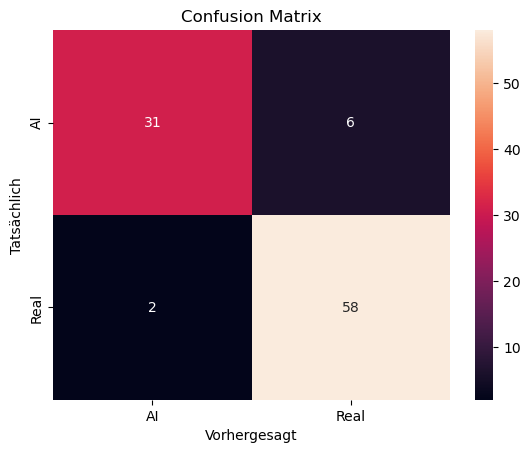

In [122]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on test data
y_pred_prob = model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_generator.y

# Classification Report (Precision, Recall, F1)
print(classification_report(y_true, y_pred, target_names=['AI', 'Real']))

# ROC-AUC Score
print(f"ROC-AUC: {roc_auc_score(y_true, y_pred_prob):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['AI', 'Real'],
            yticklabels=['AI', 'Real'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


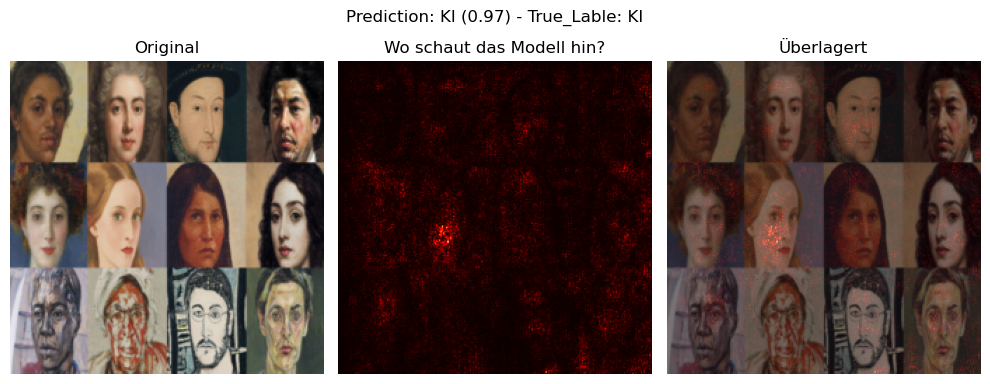

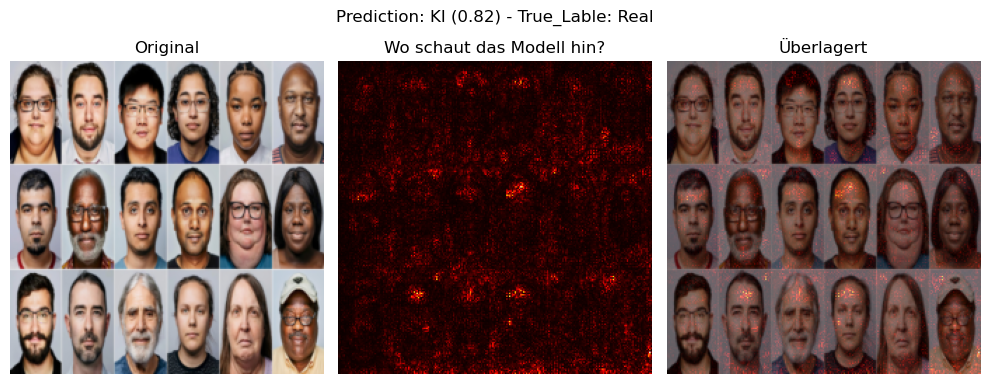

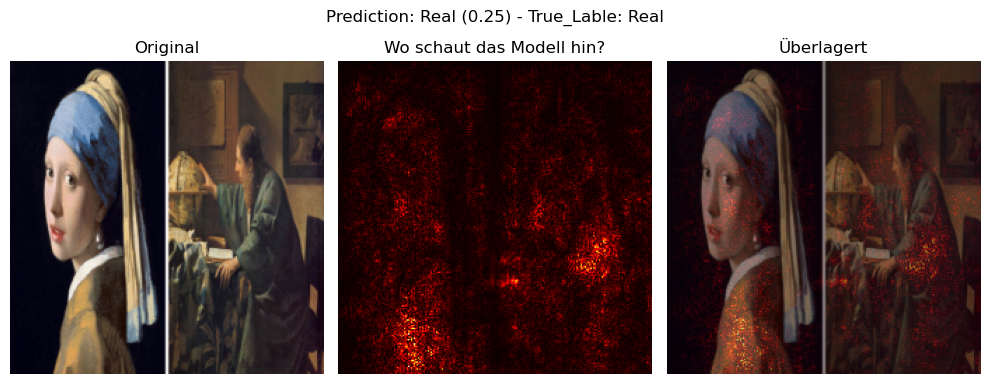

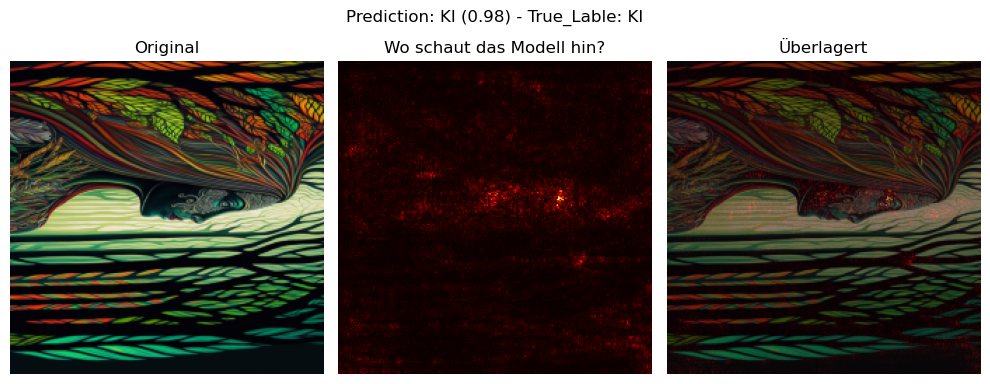

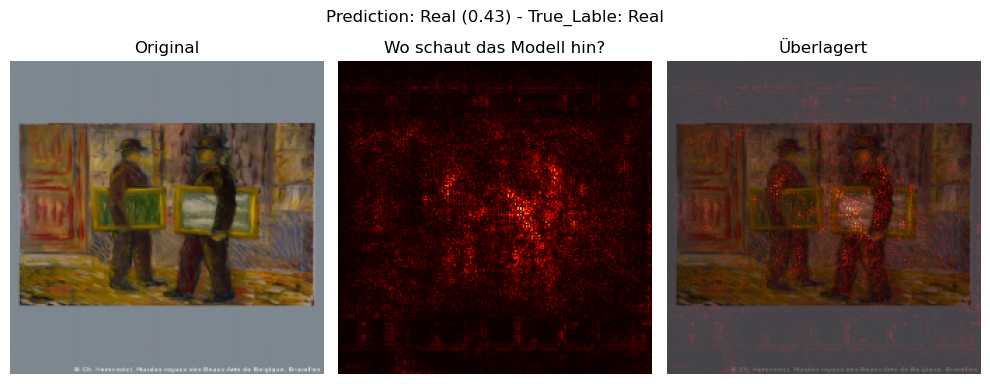

In [125]:
import tensorflow as tf


def show_saliency(model, image, true_label):
    img_tensor = tf.cast(np.expand_dims(image, axis=0), tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        prediction = model(img_tensor, training=False)
        loss = prediction[:, 0]

    grads = tape.gradient(loss, img_tensor)
    saliency = tf.reduce_max(tf.abs(grads), axis=-1)[0].numpy()
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)

    pred = float(prediction[0][0])
    label = 'AI' if pred > 0.5 else 'Real'

    # Normalize to 0-1 for display only
    display_image = image / 255.0

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(display_image)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(saliency, cmap='hot')
    plt.title("Where does the model look?")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(display_image)
    plt.imshow(saliency, cmap='hot', alpha=0.5)
    plt.title("Overlaid")
    plt.axis('off')

    plt.suptitle(f"Prediction: {label} ({pred:.2f}) - True Label: {'AI' if true_label == 1.0 else 'Real'}")
    plt.tight_layout()
    plt.show()


# Show multiple test images
for i in range(5):
    show_saliency(model, X_test[i], y_test[i])
